In [1]:
from primordialpy.background import Background
from primordialpy.model import PotentialFunction
from primordialpy.perturbations import  Perturbations
import matplotlib.pyplot as plt

## Potential

In [2]:
V = 'lambda_m*(sqrt(6)*tanh(phi/sqrt(6)))**2'
parameter = {'lambda_m': 2.05e-11}
potential = PotentialFunction.function(V, param_values=parameter)

## Background dynamics

In [3]:
background = Background(potential, phi0= 6.4)
sol = background.solver()

In [4]:
N, phi, dphidN, H, a, aH, eps_H, eta_H = background.data().values()
background.save_background(path='./Data')
Nend = N[-1]
Nend

Saved to ./Data/background.dat


np.float64(70.20702070207021)

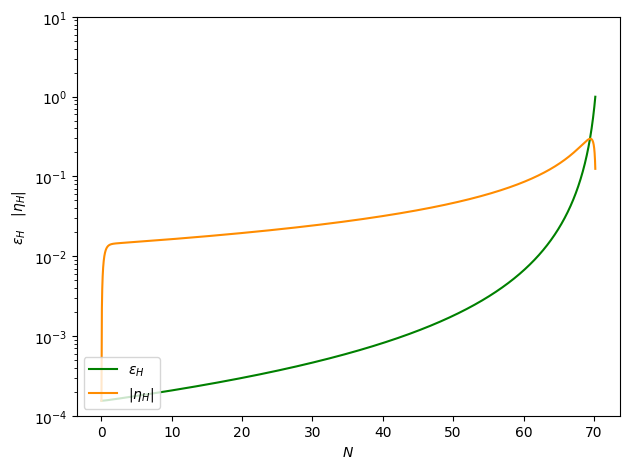

In [5]:
plt.plot(N, eps_H, label = r'$\epsilon_H$', color = 'green' )
plt.plot(N, abs(eta_H), label = r'$|\eta_H |$', color = 'darkorange')

plt.yscale('log')
plt.ylim(1e-4, 10)
plt.xlabel(r'$N$')
plt.ylabel(r'$\epsilon_H\quad |\eta_H|$')
plt.legend(loc = 3)
#plt.title('Slow-roll parameters')
plt.tight_layout()


## Perturbations and power spectra

In [6]:
pert = Perturbations(potential, background, scale= 'CMB', N_CMB = 55)
sol = pert.power_spectra_pivot()

Curvature power spectrum at pivot scale is 2.0882030317782666e-09
Tensor to scalar ratio at pivot scale is 0.0038709302970401397


In [7]:
PS = pert.power_spectrum()
pert.save_power_spectra(path ='./Data')

Computing P(k): 100%|██████████| 1000/1000 [00:23<00:00, 43.12it/s]


Saved to ./Data/power_spectra.dat


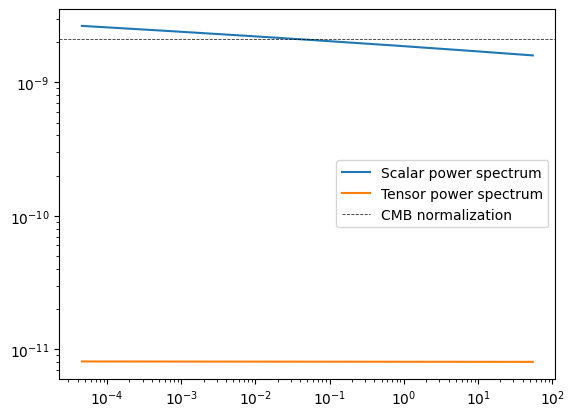

In [8]:
plt.loglog(pert.k_modes, PS[0], label = 'Scalar power spectrum')
plt.loglog(pert.k_modes, PS[1], label = 'Tensor power spectrum')
plt.axhline(y = 2.1e-9, color = 'k', label ='CMB normalization', alpha = 0.8, linewidth = 0.6, linestyle = 'dashed')
plt.legend()

In [9]:
print(pert.spectral_tilts)

{'n_s': 0.9638034512772828, 'n_t': -0.0004843585195262981}
